<a href="https://colab.research.google.com/github/rezaDamansabz/Boston_Housing_Analysis_statistics_DataScience/blob/main/Boston_Housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#“Boston Housing Data Analysis: Insights on Prices, Location, and Environmental Factors

##Project Scenario:
You are a Data Scientist with a housing agency in Boston MA, you have been given access to a previous dataset on housing prices derived from the U.S. Census Service to present insights to higher management. Based on your experience in Statistics, what information can you provide them to help with making an informed decision? Upper management will like to get some insight into the following.

- Is there a significant difference in the median value of houses bounded by the Charles river or not?

- Is there a difference in median values of houses of each proportion of owner-occupied units built before 1940?

- Can we conclude that there is no relationship between Nitric oxide concentrations and the proportion of non-retail business acres per town?

- What is the impact of an additional weighted distance to the five Boston employment centres on the median value of owner-occupied homes?

Using the appropriate graphs and charts, generate basic statistics and visualizations that you think will be useful for the upper management to give them important insight given the question they are asking, in your graphs, include an explanation of each statistic.



##Project Tasks:

**Task 1**: Familiarize yourself with the dataset

**Task 2**: Generate basic statistics and visualizations for upper management.

**Task 3**: Use the appropriate tests to answer the questions provided.

## Dataset Variables
The following describes the dataset variables:

·      CRIM - per capita crime rate by town

·      ZN - proportion of residential land zoned for lots over 25,000 sq.ft.

·      INDUS - proportion of non-retail business acres per town.

·      CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)

·      NOX - nitric oxides concentration (parts per 10 million)

·      RM - average number of rooms per dwelling

·      AGE - proportion of owner-occupied units built prior to 1940

·      DIS - weighted distances to five Boston employment centres

·      RAD - index of accessibility to radial highways

·      TAX - full-value property-tax rate per $10,000

·      PTRATIO - pupil-teacher ratio by town

·      LSTAT - % lower status of the population

·      MEDV - Median value of owner-occupied homes in $1000's

###Importing libraries

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

###Load the Dataset

In [3]:
#Load the dataset:
boston_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv'
boston_df=pd.read_csv(boston_url)

#Task 1:
Familiarize yourself with the dataset

In [9]:
#Check data info, and have a glance on the data
boston_df.info()
boston_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  506 non-null    int64  
 1   CRIM        506 non-null    float64
 2   ZN          506 non-null    float64
 3   INDUS       506 non-null    float64
 4   CHAS        506 non-null    float64
 5   NOX         506 non-null    float64
 6   RM          506 non-null    float64
 7   AGE         506 non-null    float64
 8   DIS         506 non-null    float64
 9   RAD         506 non-null    float64
 10  TAX         506 non-null    float64
 11  PTRATIO     506 non-null    float64
 12  LSTAT       506 non-null    float64
 13  MEDV        506 non-null    float64
dtypes: float64(13), int64(1)
memory usage: 55.5 KB


,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,252.500000,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,146.213884,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.000000,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,126.250000,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,252.500000,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,378.750000,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,505.000000,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


In [8]:
#Check for missing values
boston_df.isnull().sum()

,0
Unnamed: 0,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0


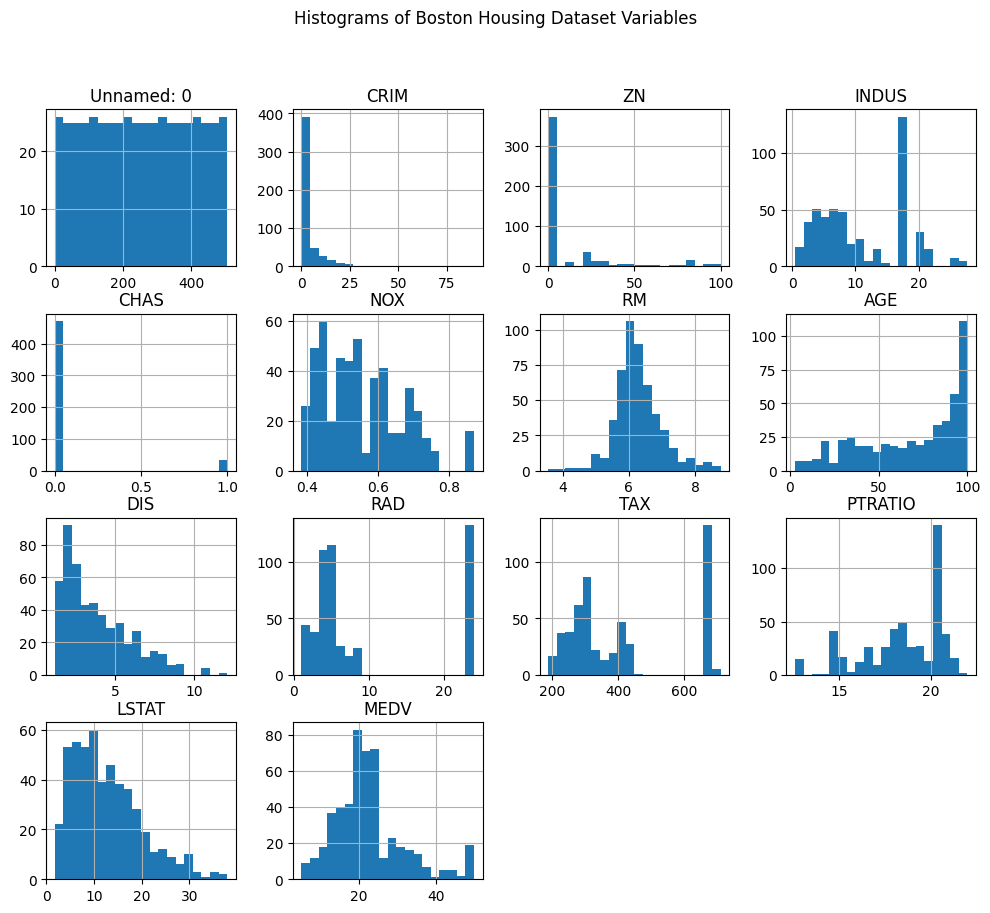

In [15]:
#Examine the distribution of variables
boston_df.hist(figsize=(12,10), bins=20)
plt.suptitle("Histograms of Boston Housing Dataset Variables")
plt.show()


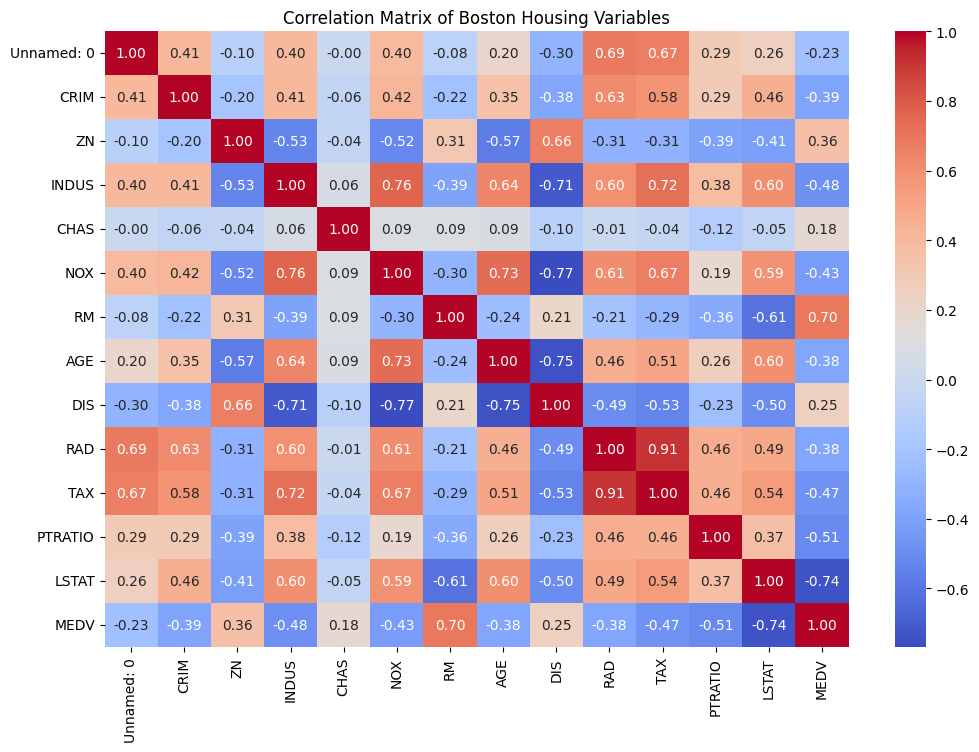

In [17]:
#Check correlations
plt.figure(figsize=(12,8))
sns.heatmap(boston_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Boston Housing Variables")
plt.show()

In [18]:
# 8. Correlation of MEDV with other variables (sorted)
print("\n----- MEDV Correlation with Other Variables -----")
print(boston_df.corr()['MEDV'].sort_values(ascending=False))


----- MEDV Correlation with Other Variables -----
MEDV          1.000000
RM            0.695360
ZN            0.360445
DIS           0.249929
CHAS          0.175260
Unnamed: 0   -0.226604
AGE          -0.376955
RAD          -0.381626
CRIM         -0.388305
NOX          -0.427321
TAX          -0.468536
INDUS        -0.483725
PTRATIO      -0.507787
LSTAT        -0.737663
Name: MEDV, dtype: float64


#Task 2:
Generate basic statistics and visualizations for upper management.

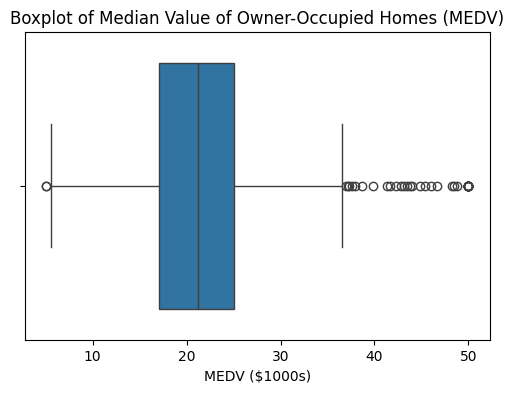

Observation: The boxplot shows the median, quartiles, and possible outliers in housing prices. Outliers indicate some extremely high-valued homes that may influence statistical tests.


In [19]:
#Boxplot for MEDV
plt.figure(figsize=(6,4))
sns.boxplot(x=boston_df['MEDV'])
plt.title("Boxplot of Median Value of Owner-Occupied Homes (MEDV)")
plt.xlabel("MEDV ($1000s)")
plt.show()

print("Observation: The boxplot shows the median, quartiles, and possible outliers in housing prices. "
      "Outliers indicate some extremely high-valued homes that may influence statistical tests.")


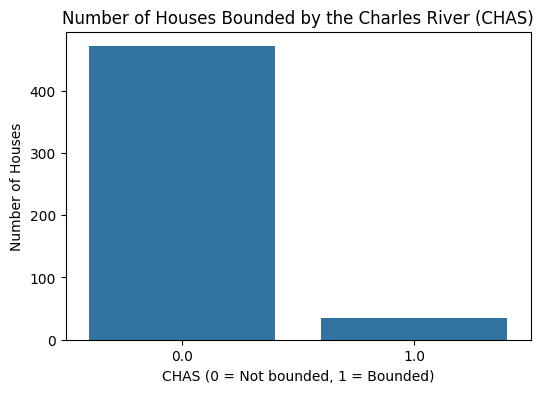

Observation: This bar plot shows how many properties are located next to the Charles River vs. not. This helps assess whether sample sizes are balanced for t-test comparisons.


In [20]:
# 2. Bar plot for Charles River variable (CHAS)
chas_counts = boston_df['CHAS'].value_counts()
plt.figure(figsize=(6,4))
sns.barplot(x=chas_counts.index, y=chas_counts.values)
plt.title("Number of Houses Bounded by the Charles River (CHAS)")
plt.xlabel("CHAS (0 = Not bounded, 1 = Bounded)")
plt.ylabel("Number of Houses")
plt.show()

print("Observation: This bar plot shows how many properties are located next to the Charles River vs. not. "
      "This helps assess whether sample sizes are balanced for t-test comparisons.")


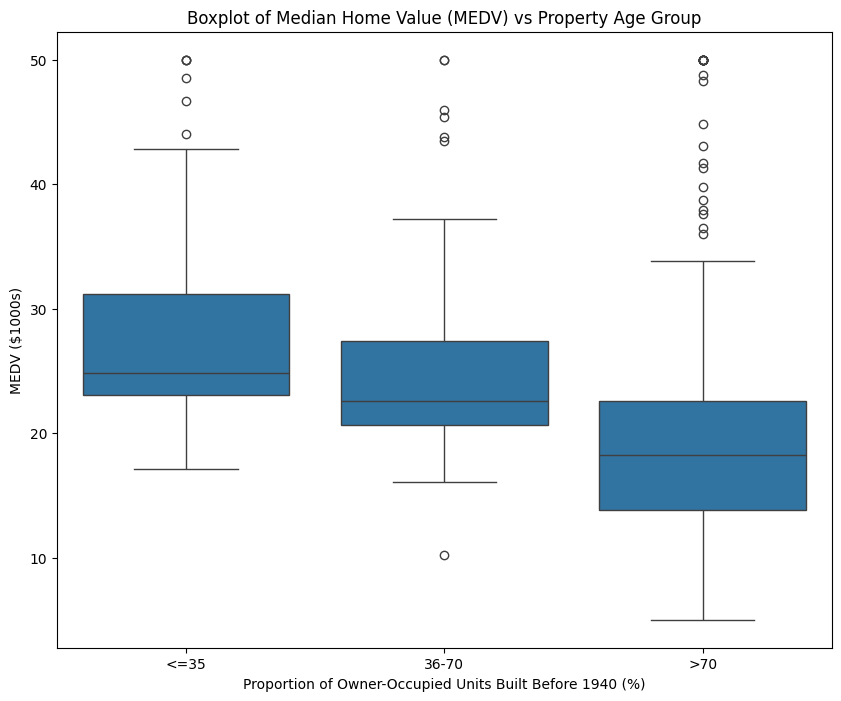

Observation: The boxplot shows how median home values vary across age groups of houses. Older properties may show different price distributions compared to newer ones.


In [25]:
# 3. Boxplot of MEDV vs AGE (discretized)
# Create AGE groups: <=35, 36-70, >70
age_bins = [0, 35, 70, 100]
age_labels = ['<=35', '36-70', '>70']
boston_df['AGE_group'] = pd.cut(boston_df['AGE'], bins=age_bins, labels=age_labels)

plt.figure(figsize=(10,8))
sns.boxplot(x='AGE_group', y='MEDV', data=boston_df)
plt.title("Boxplot of Median Home Value (MEDV) vs Property Age Group")
plt.xlabel("Proportion of Owner-Occupied Units Built Before 1940 (%)")
plt.ylabel("MEDV ($1000s)")
plt.show()

print("Observation: The boxplot shows how median home values vary across age groups of houses. "
      "Older properties may show different price distributions compared to newer ones.")


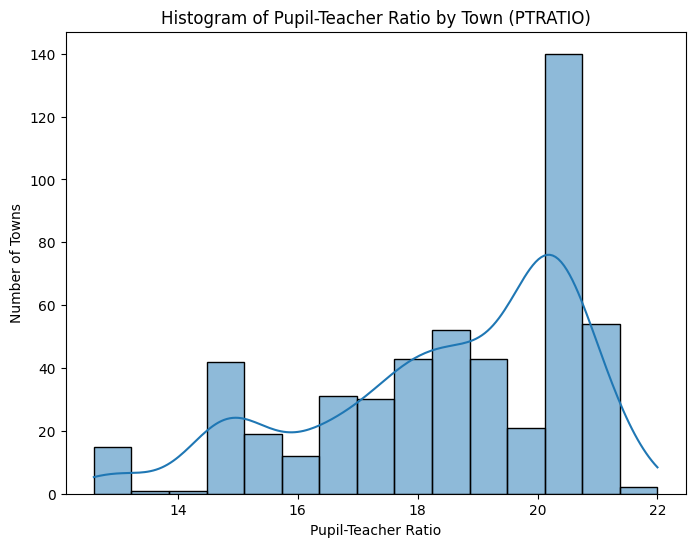

Observation: The histogram displays the distribution of pupil-teacher ratios. Most towns cluster around typical PTRATIO values, helping assess educational environment impacts.


In [27]:
# 4. Histogram for pupil-teacher ratio (PTRATIO)
plt.figure(figsize=(8,6))
sns.histplot(boston_df['PTRATIO'], bins=15, kde=True)
plt.title("Histogram of Pupil-Teacher Ratio by Town (PTRATIO)")
plt.xlabel("Pupil-Teacher Ratio")
plt.ylabel("Number of Towns")
plt.show()

print("Observation: The histogram displays the distribution of pupil-teacher ratios. "
      "Most towns cluster around typical PTRATIO values, helping assess educational environment impacts.")


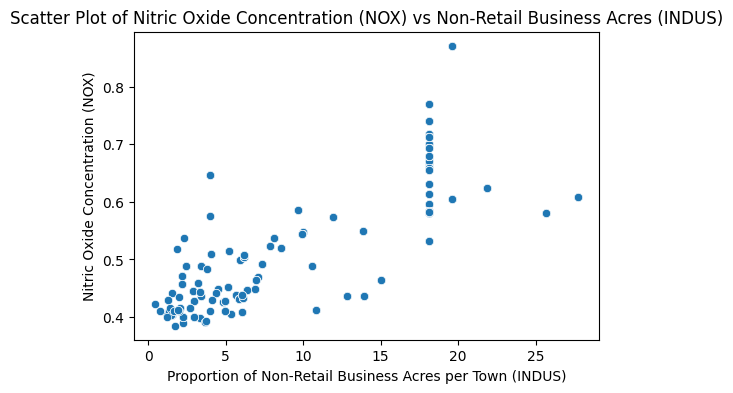

Observation: The scatter plot visualizes the relationship between NOX and INDUS. A pattern here helps determine whether correlation tests are justified.


In [28]:
# 5. Scatter plot: NOX vs INDUS
plt.figure(figsize=(6,4))
sns.scatterplot(x='INDUS', y='NOX', data=boston_df)
plt.title("Scatter Plot of Nitric Oxide Concentration (NOX) vs Non-Retail Business Acres (INDUS)")
plt.xlabel("Proportion of Non-Retail Business Acres per Town (INDUS)")
plt.ylabel("Nitric Oxide Concentration (NOX)")
plt.show()

print("Observation: The scatter plot visualizes the relationship between NOX and INDUS. "
      "A pattern here helps determine whether correlation tests are justified.")


#Task 3:
Use the appropriate tests to answer the questions provided.

In [35]:
#1. T-test: MEDV for houses by CHAS
# Hypotheses:
# H0: No difference in median house value between CHAS=0 and CHAS=1
# H1: There is a difference
#Alpha = 0.05

chas0 = boston_df[boston_df['CHAS']==0]['MEDV']
chas1 = boston_df[boston_df['CHAS']==1]['MEDV']

t_stat, p_value = stats.ttest_ind(chas0, chas1)
print("T-test for MEDV by CHAS:")
print(f"t-statistic = {t_stat:.4f}, p-value = {p_value:.4f}")

if p_value < 0.05:
    print("Conclusion: Reject H0 → Significant difference in median house values based on Charles River proximity.\n")
else:
    print("Conclusion: Fail to reject H0 → No significant difference in median house values.\n")


T-test for MEDV by CHAS:
t-statistic = -3.9964, p-value = 0.0001
Conclusion: Reject H0 → Significant difference in median house values based on Charles River proximity.



In [36]:
# 2. ANOVA: MEDV by AGE groups
# Hypotheses:
# H0: No difference in median house values among AGE groups
# H1: At least one AGE group differs

# Using AGE_group from Task 2
anova_result = stats.f_oneway(
    boston_df[boston_df['AGE_group']=='<=35']['MEDV'],
    boston_df[boston_df['AGE_group']=='36-70']['MEDV'],
    boston_df[boston_df['AGE_group']=='>70']['MEDV']
)
print("ANOVA for MEDV by AGE groups:")
print(f"F-statistic = {anova_result.statistic:.4f}, p-value = {anova_result.pvalue:.4f}")

if anova_result.pvalue < 0.05:
    print("Conclusion: Reject H0 → Median house values differ across AGE groups.\n")
else:
    print("Conclusion: Fail to reject H0 → No significant difference in median house values.\n")


ANOVA for MEDV by AGE groups:
F-statistic = 36.4076, p-value = 0.0000
Conclusion: Reject H0 → Median house values differ across AGE groups.



Pearson Correlation between NOX and INDUS:
Correlation coefficient = 0.7637, p-value = 0.0000
Conclusion: Reject H0 → There is a significant correlation between NOX and INDUS.



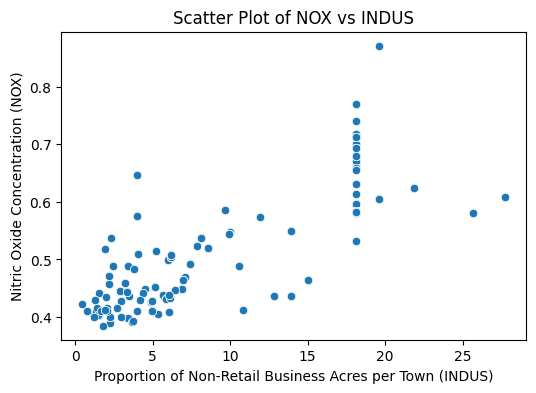

In [37]:

# 3. Pearson Correlation: NOX vs INDUS
# Hypotheses:
# H0: No correlation between NOX and INDUS
# H1: There is a correlation

corr, p_val_corr = stats.pearsonr(boston_df['NOX'], boston_df['INDUS'])
print("Pearson Correlation between NOX and INDUS:")
print(f"Correlation coefficient = {corr:.4f}, p-value = {p_val_corr:.4f}")

if p_val_corr < 0.05:
    print("Conclusion: Reject H0 → There is a significant correlation between NOX and INDUS.\n")
else:
    print("Conclusion: Fail to reject H0 → No significant correlation.\n")

# Scatter plot for NOX vs INDUS
plt.figure(figsize=(6,4))
sns.scatterplot(x='INDUS', y='NOX', data=boston_df)
plt.title("Scatter Plot of NOX vs INDUS")
plt.xlabel("Proportion of Non-Retail Business Acres per Town (INDUS)")
plt.ylabel("Nitric Oxide Concentration (NOX)")
plt.show()


In [41]:
#4. Regression: MEDV vs DIS
# ---------------------------------------
# Hypotheses:
# H0: Distance to employment centers has no effect on MEDV
# H1: Distance to employment centers affects MEDV

model = ols('MEDV ~ DIS', data=boston_df).fit()
print(model.summary())

# Interpretation
print("\nConclusion:")
if model.pvalues['DIS'] < 0.05:
    print("Reject H0 → Distance to employment centers has a significant impact on median home value.")
    print(f"Interpretation: For each additional unit of weighted distance to employment centers, "
          f"MEDV changes by {model.params['DIS']:.4f} thousand dollars on average.\n")
else:
    print("Fail to reject H0 → Distance to employment centers has no significant impact on median home value.\n")

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Tue, 04 Nov 2025   Prob (F-statistic):           1.21e-08
Time:                        18:41:44   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     18.3901      0.817     22.499      0.0